In [1]:
%cd ..

/home/blanka/Multi-Domain-Pruning


In [2]:
import os
import torch
import pandas as pd
import numpy as np
import glob

from src.model.yolo_handler import YoloHandler
from src.model.spn_handler import SPNHandler
from utils.config_parser import ConfigParser
from pruning.channel_selection.channel_selector import ChannelSelector
from state_predictor.coder import Coder
from utils.common_utils import normalize, denormalize

/data/blanka/virtualenvs/yolov10/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pruning Functions


In [3]:
def eval_pruned(alpha_sequence, model_handler, channel_selector, do_print = False):

    # Collect initial model layer info
    init_model_channels = [layer[1].out_channels for layer in model_handler.prunable_layers]

    # Select indices and prune model layer-wise
    all_indices = [None] * model_handler.n_prunable_layers
    for i, layer in enumerate(model_handler.prunable_layers):
        idxs = channel_selector.select_indices(layer[1], alpha_sequence[i])
        all_indices[i] = idxs
        model_handler.prune(all_indices, i)
        model_handler.determine_prunable_layers()

    # Collect pruned model layer info
    pruned_model_channels = [layer[1].out_channels for layer in model_handler.prunable_layers]

    # Print statistics
    if do_print:
        for i, layer in enumerate(model_handler.prunable_layers):
            n_removed_channels = init_model_channels[i] - pruned_model_channels[i]
            print(f"Layer {i:<3} {layer[0]:<20} a = {alpha_sequence[i]:<5} {n_removed_channels:<3}/{init_model_channels[i]:<5} channels removed.")

    metrics = model_handler.evaluate()
    return metrics


def eval_spn(alpha_sequence: np.ndarray, yolo_handler, spn_handler, coder, device, state_features, alpha_range, do_print_diagnostics=False):

    batch_size = 1
    predictions = []

    # Init environment
    action_batch = torch.full([batch_size, 1, yolo_handler.n_prunable_layers], -1.0).to(device)
    state_batch = torch.full([batch_size, len(state_features)-1, yolo_handler.n_prunable_layers], 1.0).to(device)
    
    for layer_i, _ in enumerate(yolo_handler.prunable_layers):

        action = alpha_sequence[layer_i]   
        action_batch[0, :, layer_i] = normalize(action, value_range=alpha_range)             
       
        spn_input_data = torch.cat((action_batch, state_batch), dim=1).view([batch_size, -1])   #.permute(0,2,1).flatten().unsqueeze(0)
        prediction = spn_handler.predict(spn_input_data)
        sparsb, dmapb = prediction[0], prediction[1]
        decoded_prediction = coder.decode_label(prediction) # Tuple([batch_size], [batch_size])

        # Update state batc        
        with torch.no_grad():
            state_batch = state_batch.clone()
            #state_batch[0, 0, layer_i] = 1
            state_batch[0, 0, layer_i] = sparsb
            state_batch[0, 1, layer_i] = dmapb

        predictions.append(decoded_prediction)

        if layer_i == 92 and do_print_diagnostics:
            df = pd.DataFrame(state_batch[0].T.cpu().numpy(), columns=['spars', 'dmap']).round(3)
            for i, row in df.iterrows():
                print(f"Layer {i:>2}: spars = {row['spars']:.3f}, dmap = {row['dmap']:.3f}")

    
    return predictions, state_batch, action_batch

## MAIN

#### Define alpha sequence

In [44]:
#init_alpha_sequence = np.linspace(2, 2.2, 93).round(1)

# Load from saved sample
sample_data_path = "/data/blanka/DATASETS/SPN/YOLOv8x_7030_modelwise_shifted_zerofilled/validation/data"
sample_pattern = "11984_*.pkl"
# Find matching data file
data_files = glob.glob(os.path.join(sample_data_path, sample_pattern))
if not data_files:
    raise FileNotFoundError(f"No data files matching pattern {sample_pattern}")
data_file = data_files[0]
state_df = pd.read_pickle(data_file)
init_alpha_sequence =  state_df["alpha"].to_numpy()[:93]

alpha_sequence = init_alpha_sequence
print(alpha_sequence)

[          0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0
           0           0           0           0           0         2.1           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0
           0           0           0           0           0           0           0           0           0           0         0.1           0         0.1         0.1           0         0.1         0.1           0           0         1.3           0         0.2         0.2           0         0.1         0.1
           0         0.2         0.6           0         0.3 

#### Load Handlers & Configs

In [5]:
spn_run_name = "20250705_000601_a9b273_optuna"
spn_conf = ConfigParser.read(f"/data/blanka/runs/SPN/YOLOv8x/prevfeat_modelwise_shifted_zerofilled/{spn_run_name}/settings.ini")
pruning_conf = ConfigParser.read("config/pruning/pruning_sampling.ini")

yolo_handler = YoloHandler(pruning_conf.model)
spn_handler = SPNHandler(spn_conf, run_name=spn_run_name)
spn_handler.create(is_pretrained=True)

channel_selector = ChannelSelector(pruning_conf.channel_selection)

alpha_range = pruning_conf.alpha.min_max_steps[:2]
state_features = spn_conf.model.state_features
device = spn_conf.train.device


# filtered_state_df = state_df[conf.model.state_features]        
# encoded_state = coder.encode_state(filtered_state_df, label_df)
# encoded_label = coder.encode_label(label_df)

# # load or define SPN model
# pred_spars, pred_dmap = spn_handler.predict(encoded_state.unsqueeze(dim=0))


/data/blanka/virtualenvs/yolov10/lib/python3.12/site-packages/ultralytics/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location

#### Evaluate Init Model & Define Coder

In [6]:
# Determine prunable layers
yolo_handler.determine_prunable_layers()
assert len(alpha_sequence) == yolo_handler.n_prunable_layers, (
f"Alpha_sequence length ({len(alpha_sequence)}) is not equal to the number of prunable layers ({yolo_handler.n_prunable_layers})!"
)

# Evaluate initial model
init_metrics = yolo_handler.evaluate()

# Load example 
sample_data_path_ex = "/data/blanka/DATASETS/SPN/YOLOv8x/data"
sample_pattern_ex = "0_*.pkl"
# Find matching data file
data_files_ex = glob.glob(os.path.join(sample_data_path_ex, sample_pattern_ex))
if not data_files_ex:
    raise FileNotFoundError(f"No data files matching pattern {sample_pattern_ex}")
data_file_ex = data_files_ex[0]
example_state_df = pd.read_pickle(data_file_ex)


coder = Coder(state_example=example_state_df, label_example=None, alpha_range=alpha_range)

Model summary (fused): 285 layers, 68132235 parameters, 24235 gradients, 257.4 GFLOPs


val: Scanning /data2/blanka/DATASETS/KITTI/testing/labels.cache... 1120 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1120/1120 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:14<00:00,  1.66s/it]

                   all       1120       7812      0.873      0.842      0.875      0.687
                   car       1120       4305      0.944       0.96      0.979      0.871
                   van       1120        430      0.941      0.965      0.982      0.859
                 truck       1120        166      0.969      0.952      0.964      0.877
            pedestrian       1120        713      0.886      0.757      0.835      0.515
        person_sitting       1120         49      0.837      0.837      0.872      0.587
               cyclist       1120        262      0.902      0.876      0.927      0.699
                  tram       1120        101      0.932       0.95      0.973      0.826
                  misc       1120        143      0.899      0.932      0.955      0.807
             dont_care       1120       1643      0.548      0.349      0.387      0.141
Speed: 0.1ms preprocess, 10.0ms inference, 0.0ms loss, 0.6ms postprocess per image


#### Prune & evaluate

In [7]:
# Eval at layer
layer_to_be_evaluated = 92
alpha_sequence = np.where(np.arange(len(init_alpha_sequence)) <= layer_to_be_evaluated, init_alpha_sequence, 0)
print(alpha_sequence)

pruned_metrics = eval_pruned(alpha_sequence, yolo_handler, channel_selector)

# Construct label
metric_features = ['recall', 'precision', 'map50', 'map90', 'n_params']
init_columns = [col + '_init' for col in metric_features]
label_df = pd.DataFrame([],columns=metric_features + ["n_layer_channels"] + init_columns)

label_df.loc[0, metric_features] = pruned_metrics
label_df.loc[0, 'n_layer_channels'] = 0
label_df.loc[0, init_columns] = init_metrics

encoded_metrics = coder.encode_label(label_df)
decoded_true_spars = denormalize(encoded_metrics[0], value_range=(0, 1))
decoded_true_dmap = denormalize(encoded_metrics[1], value_range=(0, 1))

print(f"Layer {layer_to_be_evaluated}\t spars: {decoded_true_spars:.3f}\t dmap: {decoded_true_dmap:.3f}")

[          0           0           0           0         0.1           0           0           0           0           0           0           0           0           0           0         0.1           0         0.2           0           0         0.1           0           0         0.1           0         0.1
         0.1           0         0.1         0.1         0.1         0.1         0.3           0         0.2         0.1         0.1         0.1         0.2         0.1         0.1           0         0.1         0.1           0         0.6         0.2         0.1         0.1         0.1         0.2           0
         0.3         1.3         0.1         0.2           2         0.1           0         0.1         0.3         0.3         0.1         0.1         0.2         0.2         0.1         0.6         0.1         0.6         0.1         0.1         1.9         0.2         0.9         0.6         1.6         0.1
         0.6         1.6           2         2.1         0.9 

val: Scanning /data2/blanka/DATASETS/KITTI/testing/labels.cache... 1120 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1120/1120 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:10<00:00,  1.22s/it]

                   all       1120       7812          0          0          0          0
Speed: 0.1ms preprocess, 7.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Layer 92	 spars: 0.544	 dmap: 1.000


#### Get the sample from the DB (IF RELEVANT)

In [45]:
filtered_state_df = state_df[state_features]   
encoded_state = coder.encode_state(filtered_state_df, label_df)
pred_spars, pred_dmap = spn_handler.predict(encoded_state.unsqueeze(dim=0))

df = pd.DataFrame(encoded_state.reshape(3,93).T, columns=['alpha', 'spars', 'dmap']).round(3)
#df = pd.DataFrame(encoded_state.reshape(93,3), columns=['alpha', 'spars', 'dmap']).round(3)
spn_preds_from_gt = df
# for i, row in df.iterrows():
#     print(f"Layer {i:>2}: spars = {row['spars']:.3f}, dmap = {row['dmap']:.3f}")

# Denormalize the encoded label
decoded_pred_spars = denormalize(pred_spars, value_range=(0, 1))
decoded_pred_dmap = denormalize(pred_dmap, value_range=(0, 1))
print(f"Layer 92 \t spars: {decoded_pred_spars.item():.3f}\t dmap: {decoded_pred_dmap.item():.3f}")

Layer 92 	 spars: 0.099	 dmap: 0.141


#### Prepare stuff for SPN

In [46]:
spn_predictions_decoded, batch_state, actions_to_plot = eval_spn(alpha_sequence, yolo_handler, spn_handler, coder, device, state_features, alpha_range, do_print_diagnostics=False)
spn_preds_from_scratch = batch_state

# print("\n\n ####### Results Denormalized #######")
# for i, (pred, alpha) in enumerate(zip(spn_predictions_decoded, alpha_sequence)):

#     tab = "\t" if i>9 else "\t\t"
#     print(f"Layer {i}{tab} {alpha}\t spars: {pred['spars'].item():.3f}\t dmap: {pred['dmap'].item():.3f}")


## PLOT PREDICTIONS

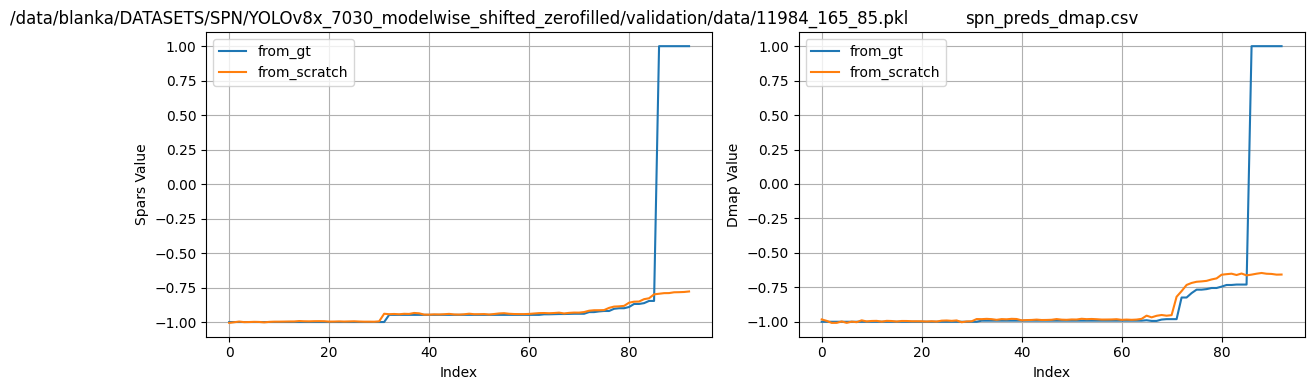

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Suppose your data is already loaded
data_file_spars = 'spn_preds_spars.csv'
data_file_dmap = 'spn_preds_dmap.csv'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot for "spars"
x_spars = np.arange(len(spn_preds_from_gt['spars']))
y1_spars = spn_preds_from_gt['spars'].reset_index(drop=True)
y2_spars = spn_preds_from_scratch[0, -2, :].cpu()
alpha = actions_to_plot[0,0,:].cpu()

axes[0].plot(x_spars, y1_spars, label='from_gt')
axes[0].plot(x_spars, y2_spars, label='from_scratch')
#axes[0].plot(x_spars, alpha, label='alpha')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Spars Value')
axes[0].set_title(data_files[0])
axes[0].legend()
axes[0].grid()



# Plot for "dmap"
x_dmap = np.arange(len(spn_preds_from_gt['dmap']))
y1_dmap = spn_preds_from_gt['dmap'].reset_index(drop=True)
y2_dmap = spn_preds_from_scratch[0, -1, :].cpu()

axes[1].plot(x_dmap, y1_dmap, label='from_gt')
axes[1].plot(x_dmap, y2_dmap, label='from_scratch')
#axes[1].plot(x_dmap, alpha, label='alpha')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Dmap Value')
axes[1].set_title(data_file_dmap)
axes[1].legend()
axes[1].grid()


plt.tight_layout()
plt.show()
